#**Muhammad Huzaifa**

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7586 - loss: 0.8141 - val_accuracy: 0.9133 - val_loss: 0.3031
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.9176 - loss: 0.2993 - val_accuracy: 0.9183 - val_loss: 0.2769
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9239 - loss: 0.2681 - val_accuracy: 0.9247 - val_loss: 0.2567
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9307 - loss: 0.2507 - val_accuracy: 0.9307 - val_loss: 0.2438
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9350 - loss: 0.2360 - val_accuracy: 0.9288 - val_loss: 0.2433
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9375 - loss: 0.2216 - val_accuracy: 0.9311 - val_loss: 0.2327
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9391 - loss: 0.2142 - val_accuracy: 0.9326 - val_loss: 0.2373
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9419 - loss: 0.2053 - 

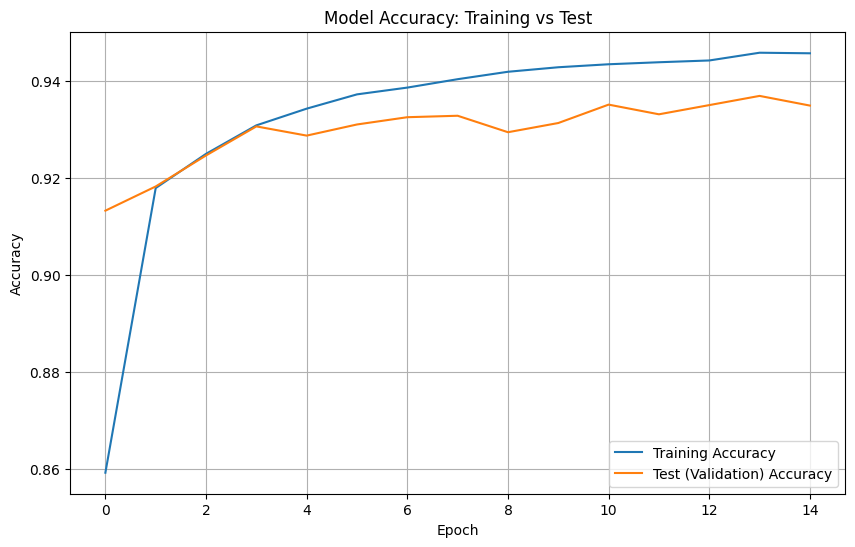

Final Test Accuracy: 93.50%


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the MNIST dataset
# The dataset is already split into train and test sets by Keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# 2. Preprocess the data
# Normalize pixel values to be between 0 and 1 (standard practice for neural networks)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# 3. Define the Model Architecture
# Constraint: Input (784) -> Hidden (10 neurons, ReLU) -> Output (10 neurons, Softmax)
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)), # Flattens 28x28 images into 784 vector
    keras.layers.Dense(10, activation='relu'),  # Hidden layer with 10 neurons
    keras.layers.Dense(10, activation='softmax') # Output layer with 10 neurons
])

# 4. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 5. Train the Model
# We use a validation_split or pass validation_data to track test accuracy during training
history = model.history = model.fit(X_train, y_train,
                                    epochs=15,
                                    batch_size=32,
                                    validation_data=(X_test, y_test),
                                    verbose=1)

# 6. Plotting Accuracy vs Epoch
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Test (Validation) Accuracy')
plt.title('Model Accuracy: Training vs Test')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 7. Evaluate Final Performance
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")